In [1]:
%load_ext autoreload
%autoreload 2

import os
import argparse
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.visualization_utils as visualization_utils
import utils.stats_utils as stats_utils
from constants.behavioral_constants import *
from constants.decoding_constants import *
from scripts.pseudo_decoding.belief_partitions.belief_partition_configs import *
import scripts.pseudo_decoding.belief_partitions.belief_partitions_io as belief_partitions_io
from scripts.pseudo_decoding.belief_partitions.decode_pref_on_choice_axis import get_proj_mode

plt.rcParams.update({"font.size": 16})

# One row per decoder, on disjoint halves of group B

The stacked figures of [20260810_visualize_pref_on_choice_axis.ipynb](20260810_visualize_pref_on_choice_axis.ipynb),
re-read against the B split runs of `claude_notes/stim_belief_alignment_updated.md` Issue 2.

Relative to a feature X, over correct trials, that note's three groups are

| group | `BeliefPartition` | `Choice` |
| --- | --- | --- |
| A | High Not X | Not Chose |
| B | High Not X | Chose |
| C | High X | Chose |

so the stimulus axis is A vs. B and the conditions read out along it are B vs. C. Group B is on
both sides of that. In the earlier runs every B trial trained the axis **and** was one of the two
classes scored along it, so its own noise helped build the axis and it projected further toward the
Chose end than a fresh B trial would. The ordering along this axis is A < B < C with C the positive
class, so that leak pushed B *toward* C and closed the very gap being measured — it deflated
projected accuracy rather than inflating it, and refitting the threshold could not undo it, since
the shift moved one scored class and not the other.

Here B is split into disjoint halves by `stim_belief_groups.draw_b_split`: the axis is fit on
**B1** (`b_split_half=1`) and the scored conditions keep **B2** only (`b_split_half=2`). No trial
does both jobs. The cost is trials — B goes from ~65 to ~33, and the balance step takes the other
class down to match — so both decoders sit on roughly 33 trials per class rather than ~47-65.

| row | mode | trials, units | path |
| --- | --- | --- | --- |
| stim | `choice` | `Response Correct`, `BeliefPartition High Not X`, **B1**, all units | `/data/patrick_res/choice_reward/..._b_split_half_1` |
| preference | `pref` | `Response Correct`, `Choice Chose`, **B2**, `pref_99th_window_filter_drift` | `/data/patrick_res/belief_partitions/..._b_split_half_2` |
| pref on stim ax | `pref_on_choice_..._axis_b_split_half_1` | same as preference | `/data/patrick_res/choice_axis_projection_accs/..._b_split_half_2` |

Rows 1 and 2 are decoders fit to their own conditions; only row 3 has a fixed direction. Rows 1 and
2 are not on the same trials or units, so the comparison of interest is each row against its own
shuffle, not row 1's height against row 2's.

Each panel shows one series against its own session-permute shuffle, with a row of significance
bars beneath (one-sided permutation test, `stats_utils.compute_p_for_decoding_by_time`). Only the
projection has a `*_pvals.pickle` on disk; the two decoder rows have none, so theirs are computed
here — same test, so the three rows stay comparable.

In [2]:
# The B split runs. Group B is halved by stim_belief_groups.draw_b_split, deterministically in
# (session, feat, train_test_seed, shuffle_idx), so the halves below are the same ones the cosine
# analysis and the single unit anova use.
AXIS_BEH_FILTERS = {"Response": "Correct", "BeliefPartition": "High Not X"}
# half of B the stimulus axis was fit on, and the half the scored runs kept. Complementary by
# construction: that is the whole point, see the markdown above
AXIS_B_SPLIT_HALF = 1
B_SPLIT_HALF = 2
# the axis's filters AND its half are both part of the mode name, so projections onto different
# axes sit side by side rather than overwriting each other
PROJ_MODE = get_proj_mode(AXIS_BEH_FILTERS, AXIS_B_SPLIT_HALF)

MODE_TO_BASE_PATH = {
    "pref": "/data/patrick_res/belief_partitions",
    PROJ_MODE: "/data/patrick_res/choice_axis_projection_accs",
    # choice decoding fit on all units, the runs decode_pref_on_choice_axis.load_choice_axes
    # takes its axis from
    "choice": "/data/patrick_res/choice_reward",
}

# the B split grid was run feedback aligned only
TRIAL_EVENTS = ["FeedbackOnsetLong"]

# one mode per row of the stacked figure, top to bottom
ROW_MODES = ["choice", "pref", PROJ_MODE]

# Display names for the legends. The `choice` mode is labelled "stim", since with these
# AXIS_BEH_FILTERS the axis it provides is the A vs. B stimulus axis, not a choice axis.
SERIES_NAMES = {
    "pref": "preference",
    "pref_shuffle": "preference shuffle",
    PROJ_MODE: "pref on stim ax",
    f"{PROJ_MODE}_shuffle": "pref on stim ax shuffle",
    "choice": "stim",
    "choice_shuffle": "stim shuffle",
}
SERIES_TO_COLOR = {
    "preference": "tab:blue",
    "preference shuffle": "#aec7e8",
    "pref on stim ax": "tab:purple",
    "pref on stim ax shuffle": "#c5b0d5",
    "stim": "tab:orange",
    "stim shuffle": "#ffbb78",
}

# whole population, then the 6 regions of interest, labelled by their abbreviations
POPULATIONS = [(None, None, "whole population")] + [
    ("structure_level2_cleaned", region, visualization_utils.REGION_TO_ABBREV[region])
    for region in REGIONS_OF_INTEREST
]


def get_args(mode, region_level, regions, trial_event):
    """
    Configs for one mode's run: the trials and units it ran on, and the path it's stored under
    """
    args = argparse.Namespace(**BeliefPartitionConfigs()._asdict())
    args.subject = "both"
    args.mode = mode
    if mode == "choice":
        # the all units choice runs use no subpopulation, and only the trials AXIS_BEH_FILTERS
        # names -- matching what decode_pref_on_choice_axis.load_choice_axes reads for the same
        # filters, see slurm_launch_stim_belief_decoding_b_split.sh
        args.beh_filters = AXIS_BEH_FILTERS
        args.sig_unit_level = None
    else:
        args.beh_filters = {"Response": "Correct", "Choice": "Chose"}
        args.sig_unit_level = "pref_99th_window_filter_drift"
    # the axis run kept B1, the two scored runs kept B2. b_split_half names the directory, so this
    # is what points every read at the split runs rather than the earlier full-B ones
    args.b_split_half = AXIS_B_SPLIT_HALF if mode == "choice" else B_SPLIT_HALF
    args.region_level = region_level
    args.regions = regions
    args.trial_event = trial_event
    args.base_output_path = MODE_TO_BASE_PATH[mode]
    return args


def read_modes(region_level, regions, trial_event, modes=ROW_MODES):
    """
    Reads each mode's accuracies, with their shuffles, into one frame
    """
    res = []
    for mode in modes:
        args = get_args(mode, region_level, regions, trial_event)
        res.append(belief_partitions_io.read_results(args, FEATURES))
    res = pd.concat(res)
    res["series"] = res["mode"].map(SERIES_NAMES)
    res["trial_event"] = trial_event
    return res


PVALS = {}


def get_pvals_for_mode(mode, region_level, regions, trial_event, res=None):
    """
    One mode's per-timepoint p value against its own shuffle: read off disk if it is there,
    otherwise computed here and cached.

    Only the projection has a pickle, written by
    p_val_computations/compute_p_vals_for_pref_on_choice.py. Neither decoder row does --
    compute_p_vals_for_decoders.py covers only the *_99th_window_filter_drift_units choice dirs,
    not the all-unit ones, and nothing writes p values for the B split preference runs. Computing
    the missing ones here is the same one-sided permutation test that script would have written,
    run over the results already in memory, so all three rows are read the same way.

    `res` lets a mode reuse an already read frame instead of hitting disk again.
    """
    key = (mode, regions, trial_event)
    if key in PVALS:
        return PVALS[key]

    args = get_args(mode, region_level, regions, trial_event)
    path = os.path.join(belief_partitions_io.get_dir_name(args, make_dir=False), f"{mode}_pvals.pickle")
    if os.path.exists(path):
        PVALS[key] = pd.read_pickle(path)
    else:
        print(f"no p values on disk for {mode} / {regions or 'whole population'}, computing")
        if res is None:
            res = belief_partitions_io.read_results(args, FEATURES)
        else:
            res = res[res["mode"].isin([mode, f"{mode}_shuffle"])].copy()
        PVALS[key] = stats_utils.compute_p_for_decoding_by_time(res, args)
    return PVALS[key]


def read_pvals(region_level, regions, trial_event, modes=ROW_MODES, res=None):
    """
    Each mode's per-timepoint p values, keyed by series name
    """
    return {
        SERIES_NAMES[mode]: get_pvals_for_mode(mode, region_level, regions, trial_event, res)
        for mode in modes
    }

In [3]:
def format_event_axis(ax, trial_event, with_xlabel=True):
    """
    Event markers, ticks and x label for one trial event's column of axes
    """
    ax.axvline(0, color="grey", linestyle="dotted", linewidth=3)
    if trial_event == "StimOnset":
        ax.axvline(-.5, color="grey", linestyle="dotted", linewidth=3)
        ticks = [-1, -.5, 0, .5, 1]
        label = "Time to stimuli appear (s)"
    else:
        ax.axvline(-.8, color="grey", linestyle="dotted", linewidth=3)
        ticks = [-1.5, -1, -.5, 0, .5, 1, 1.5]
        label = "Time to feedback (s)"
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks)
    ax.set_xlabel(label if with_xlabel else None)


def plot_stacked_accs(region_level, regions, title=None, trial_events=None):
    """
    One row per mode rather than overlaying them: the stimulus axis on top, preference, then
    preference projected onto that axis. Columns are the trial events, TRIAL_EVENTS by default,
    and every panel shares a y axis so the rows can be read against each other.
    """
    trial_events = TRIAL_EVENTS if trial_events is None else trial_events
    res = {
        trial_event: read_modes(region_level, regions, trial_event, modes=ROW_MODES)
        for trial_event in trial_events
    }

    fig, axs = plt.subplots(
        len(ROW_MODES), len(trial_events),
        # 5.5in per column plus 4in for y axis and legend
        figsize=(4 + 5.5 * len(trial_events), 3 * len(ROW_MODES)),
        sharey=True, sharex="col", squeeze=False,
        width_ratios=[res[trial_event].Time.nunique() for trial_event in trial_events]
    )
    for row, mode in enumerate(ROW_MODES):
        # the mode's own trace and its shuffle, nothing else in the panel
        series = [SERIES_NAMES[mode], SERIES_NAMES[f"{mode}_shuffle"]]
        for col, trial_event in enumerate(trial_events):
            ax = axs[row, col]
            sns.lineplot(
                res[trial_event][res[trial_event].series.isin(series)],
                x="Time", y="Accuracy", hue="series", hue_order=series,
                palette=SERIES_TO_COLOR, linewidth=3, ax=ax, errorbar="se"
            )
            ax.axhline(y=0.5, linestyle="dotted", color="black")
            format_event_axis(ax, trial_event, with_xlabel=row == len(ROW_MODES) - 1)

    # one row of significance bars per panel, that mode against its own shuffle, colored to
    # match the trace. Read the shared limits before any bar can rescale the axes.
    bottom, top = axs[0, 0].get_ylim()
    spacing = 0.08 * (top - bottom)
    for row, mode in enumerate(ROW_MODES):
        for col, trial_event in enumerate(trial_events):
            p_vals = read_pvals(
                region_level, regions, trial_event, modes=[mode], res=res[trial_event]
            )
            visualization_utils.plot_sig_bars(
                p_vals[SERIES_NAMES[mode]], bottom - spacing, axs[row, col],
                color=SERIES_TO_COLOR[SERIES_NAMES[mode]]
            )
    # shared y, so these set every panel: room for the bars without rescaling the traces, and
    # ticks kept on the traces, since an accuracy tick in the bar strip reads as data
    axs[0, 0].set_ylim(bottom - 1.5 * spacing, top)
    axs[0, 0].set_yticks([tick for tick in axs[0, 0].get_yticks() if bottom <= tick <= top])

    visualization_utils.format_plot(axs)
    for row in range(len(ROW_MODES)):
        axs[row, 0].set_ylabel("Accuracy")
        for col in range(1, len(trial_events)):
            axs[row, col].set_ylabel(None)
        for col in range(len(trial_events) - 1):
            axs[row, col].get_legend().remove()
        # per row, since each row names its own pair of series
        legend = axs[row, -1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
        for line in legend.get_lines():
            line.set_linewidth(6)
    if title:
        axs[0, 0].set_title(title, loc="left")
    fig.tight_layout()
    return fig, axs, pd.concat(res.values())

## Whole population, stacked

no p values on disk for choice / whole population, computing


100%|██████████| 33/33 [00:05<00:00,  6.21it/s]


no p values on disk for pref / whole population, computing


100%|██████████| 33/33 [00:00<00:00, 45.57it/s]


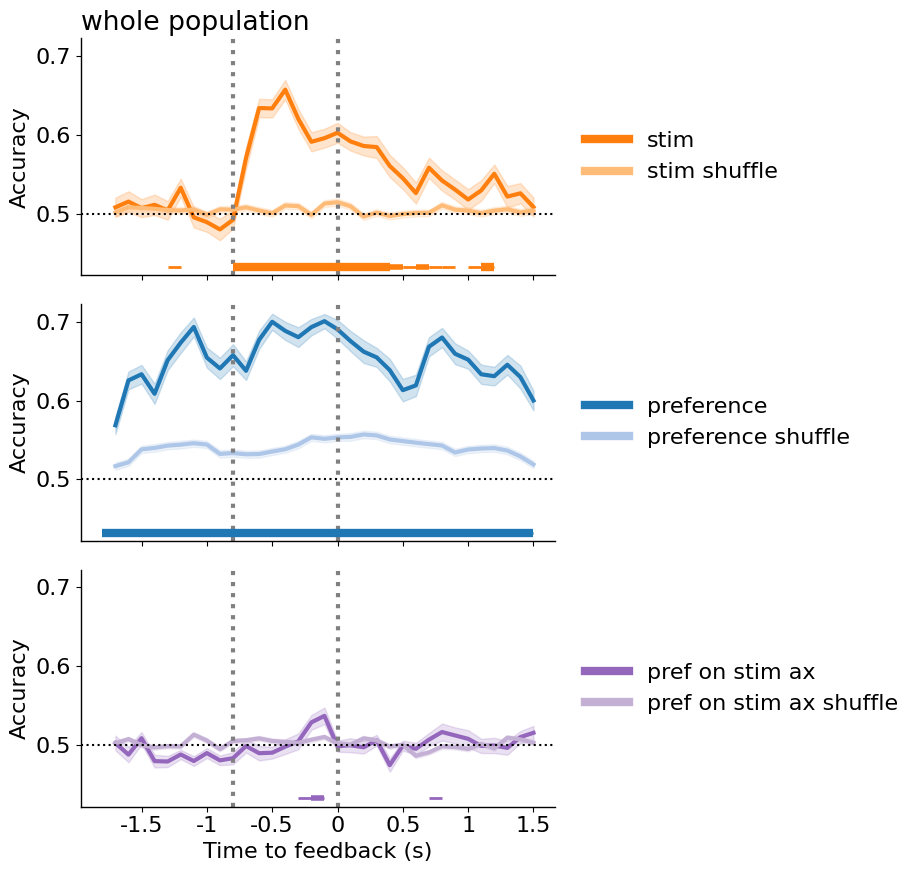

In [4]:
fig, _, whole_pop_stacked_res = plot_stacked_accs(None, None, title="whole population")

## Regions of interest, stacked

no p values on disk for choice / amygdala_Amy, computing


100%|██████████| 33/33 [00:00<00:00, 43.77it/s]


no p values on disk for pref / amygdala_Amy, computing


100%|██████████| 33/33 [00:00<00:00, 44.30it/s]


no p values on disk for choice / basal_ganglia_BG, computing


...

100%|██████████| 33/33 [00:00<00:00, 44.58it/s]


no p values on disk for choice / anterior_cingulate_gyrus_ACgG, computing


100%|██████████| 33/33 [00:00<00:00, 43.85it/s]


no p values on disk for pref / anterior_cingulate_gyrus_ACgG, computing


100%|██████████| 33/33 [00:00<00:00, 44.09it/s]


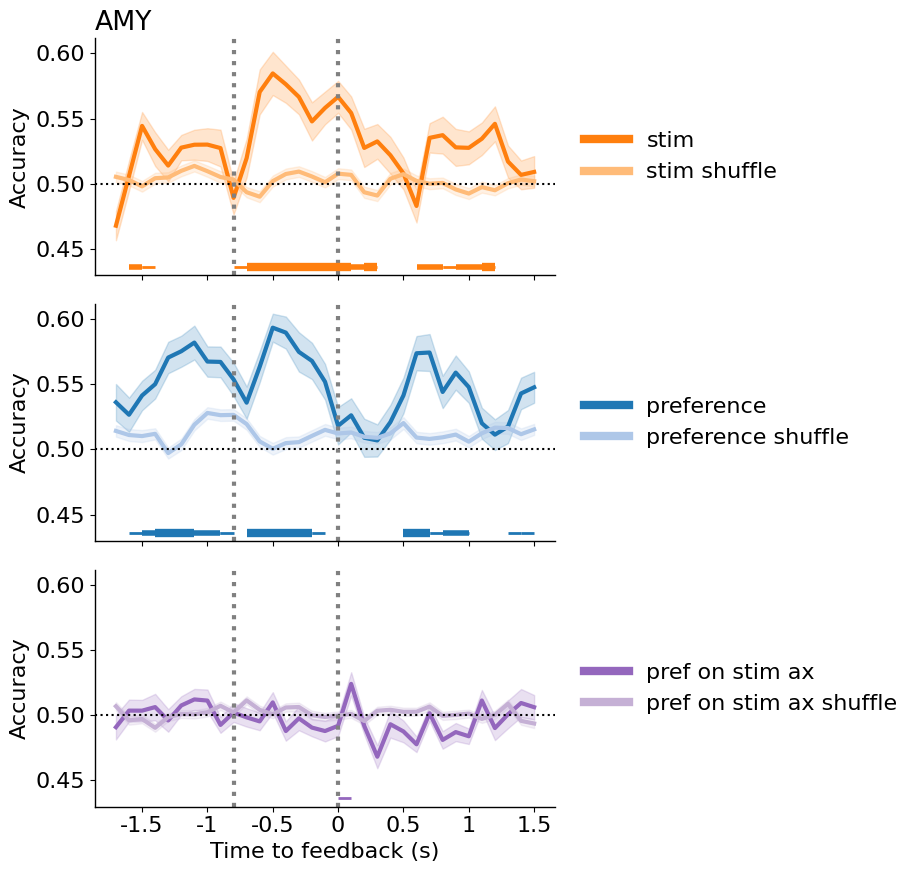

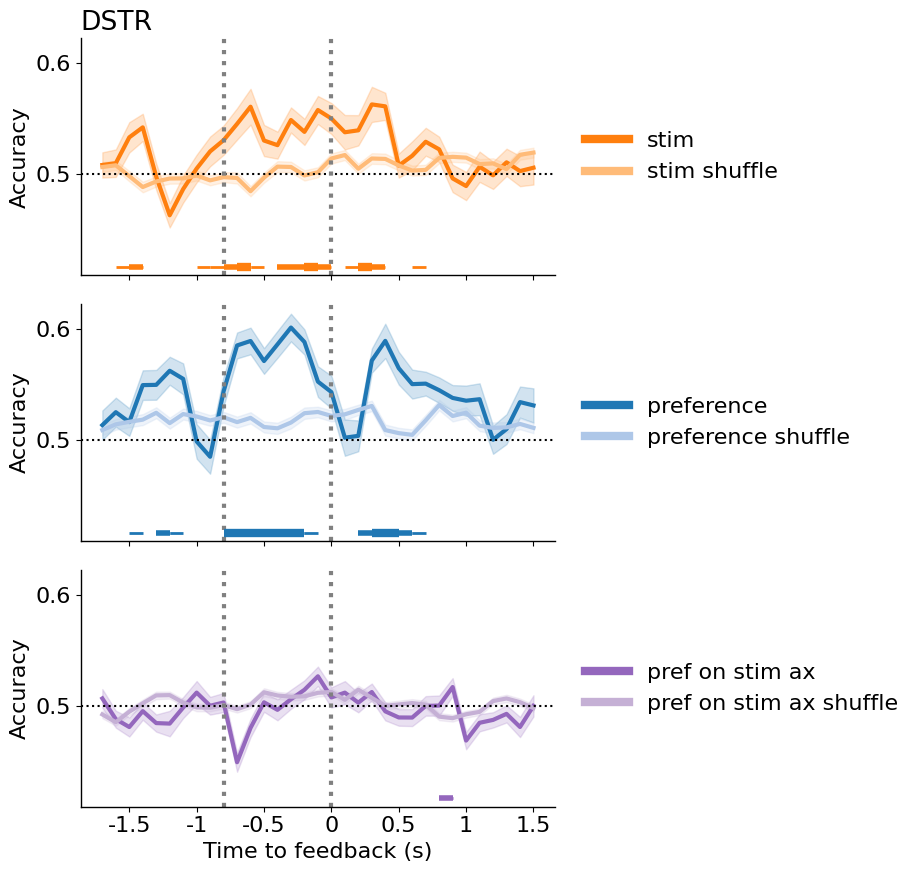

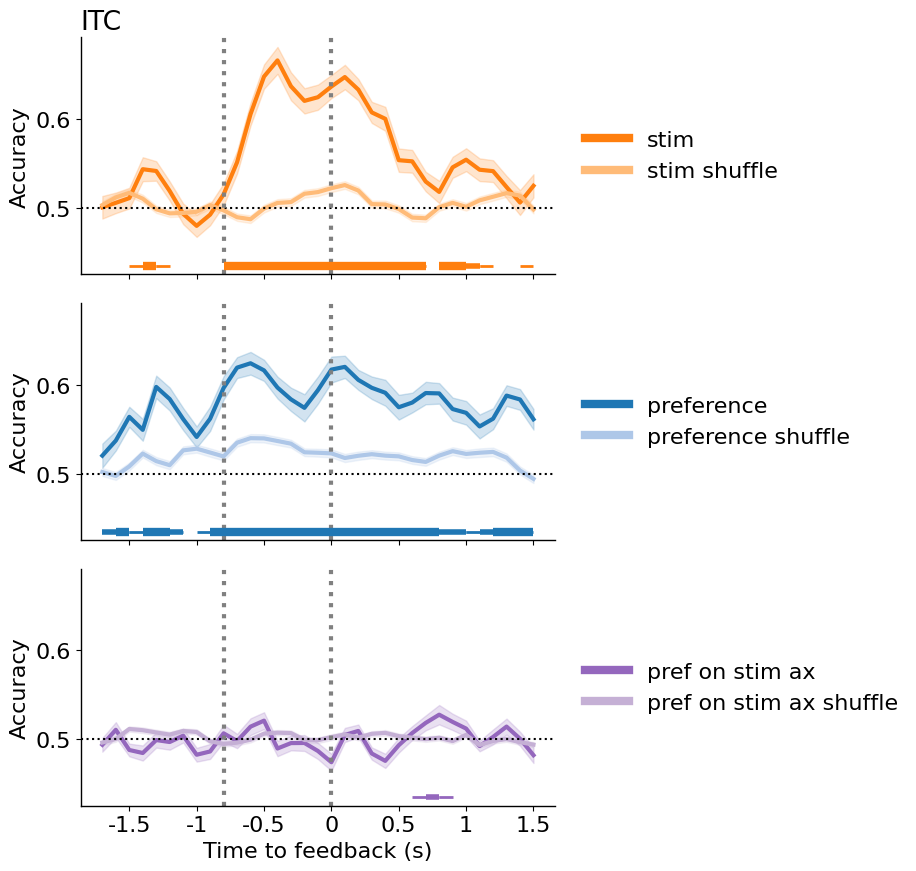

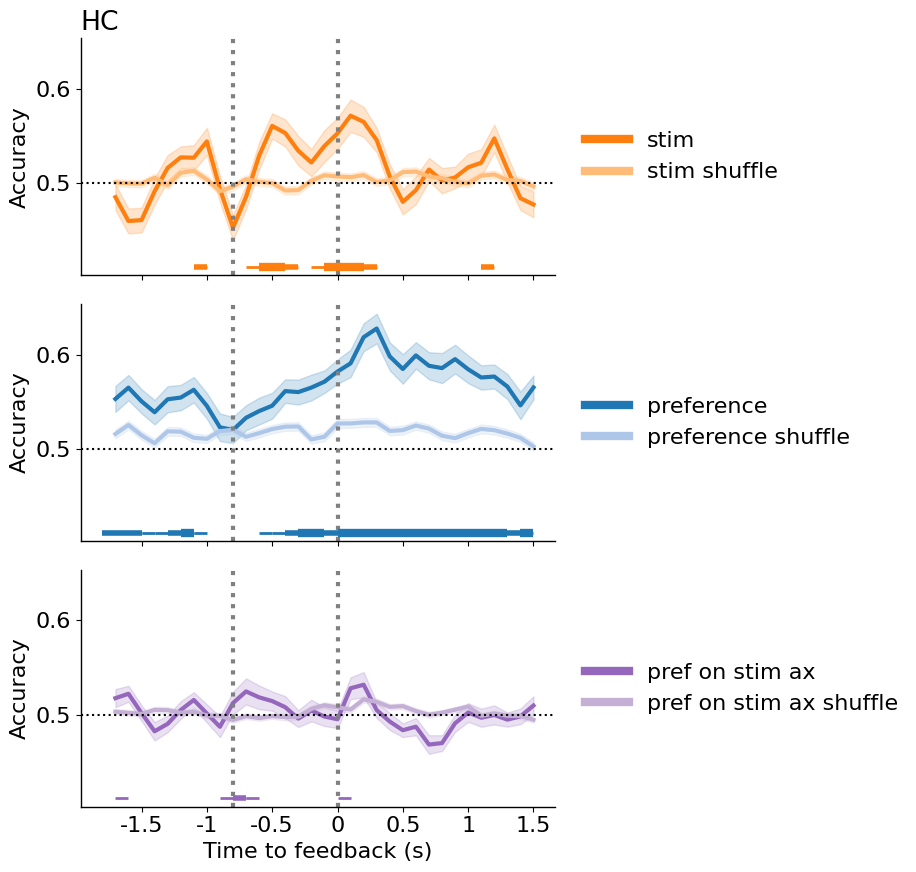

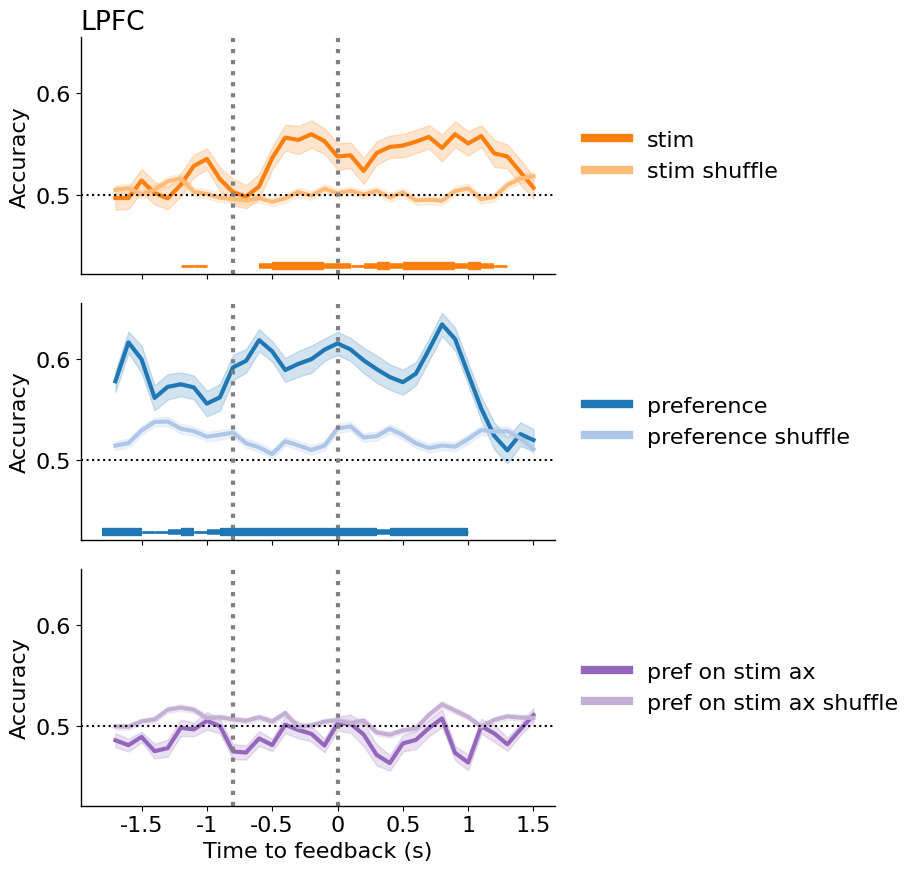

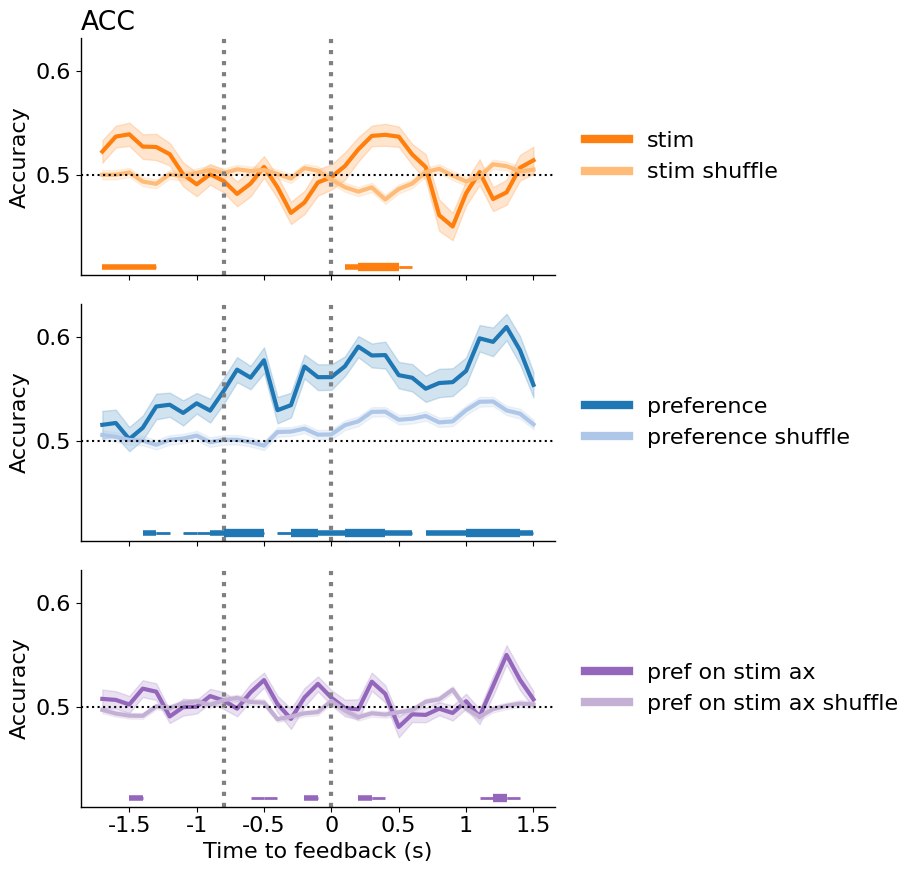

In [5]:
all_stacked_res = [whole_pop_stacked_res.assign(population="whole population")]
for region_level, regions, name in POPULATIONS[1:]:
    _, _, res = plot_stacked_accs(region_level, regions, title=name)
    all_stacked_res.append(res.assign(population=name))
all_stacked_res = pd.concat(all_stacked_res)